# Simulating Korea COVID-19 Data (2020-2023)

This simulation runs Covasim with different parameters and calibration points.

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import covasim as cv

plt.style.use('seaborn-v0_8')

Covasim 3.1.7 (2026-02-18) — © 2020-2026 by IDM


In [2]:
covasim_df = pd.read_csv("/home/jhkim/covasim_project/jhk_covasim4wastewater/simulation_korea/korea_clean_for_covasim.csv")
covasim_df["date"] = pd.to_datetime(covasim_df["date"])
covasim_df.head()

,date,new_diagnoses,new_deaths
0,2020-01-20,1.0,0.0
1,2020-01-21,0.0,0.0
2,2020-01-22,0.0,0.0
3,2020-01-23,0.0,0.0
4,2020-01-24,1.0,0.0


# Visualizing the Epidemic Curves

We now visualize:
- Daily new diagnoses  
- Daily deaths  

These plots provide a high‑level overview of the epidemic trajectory in Korea.

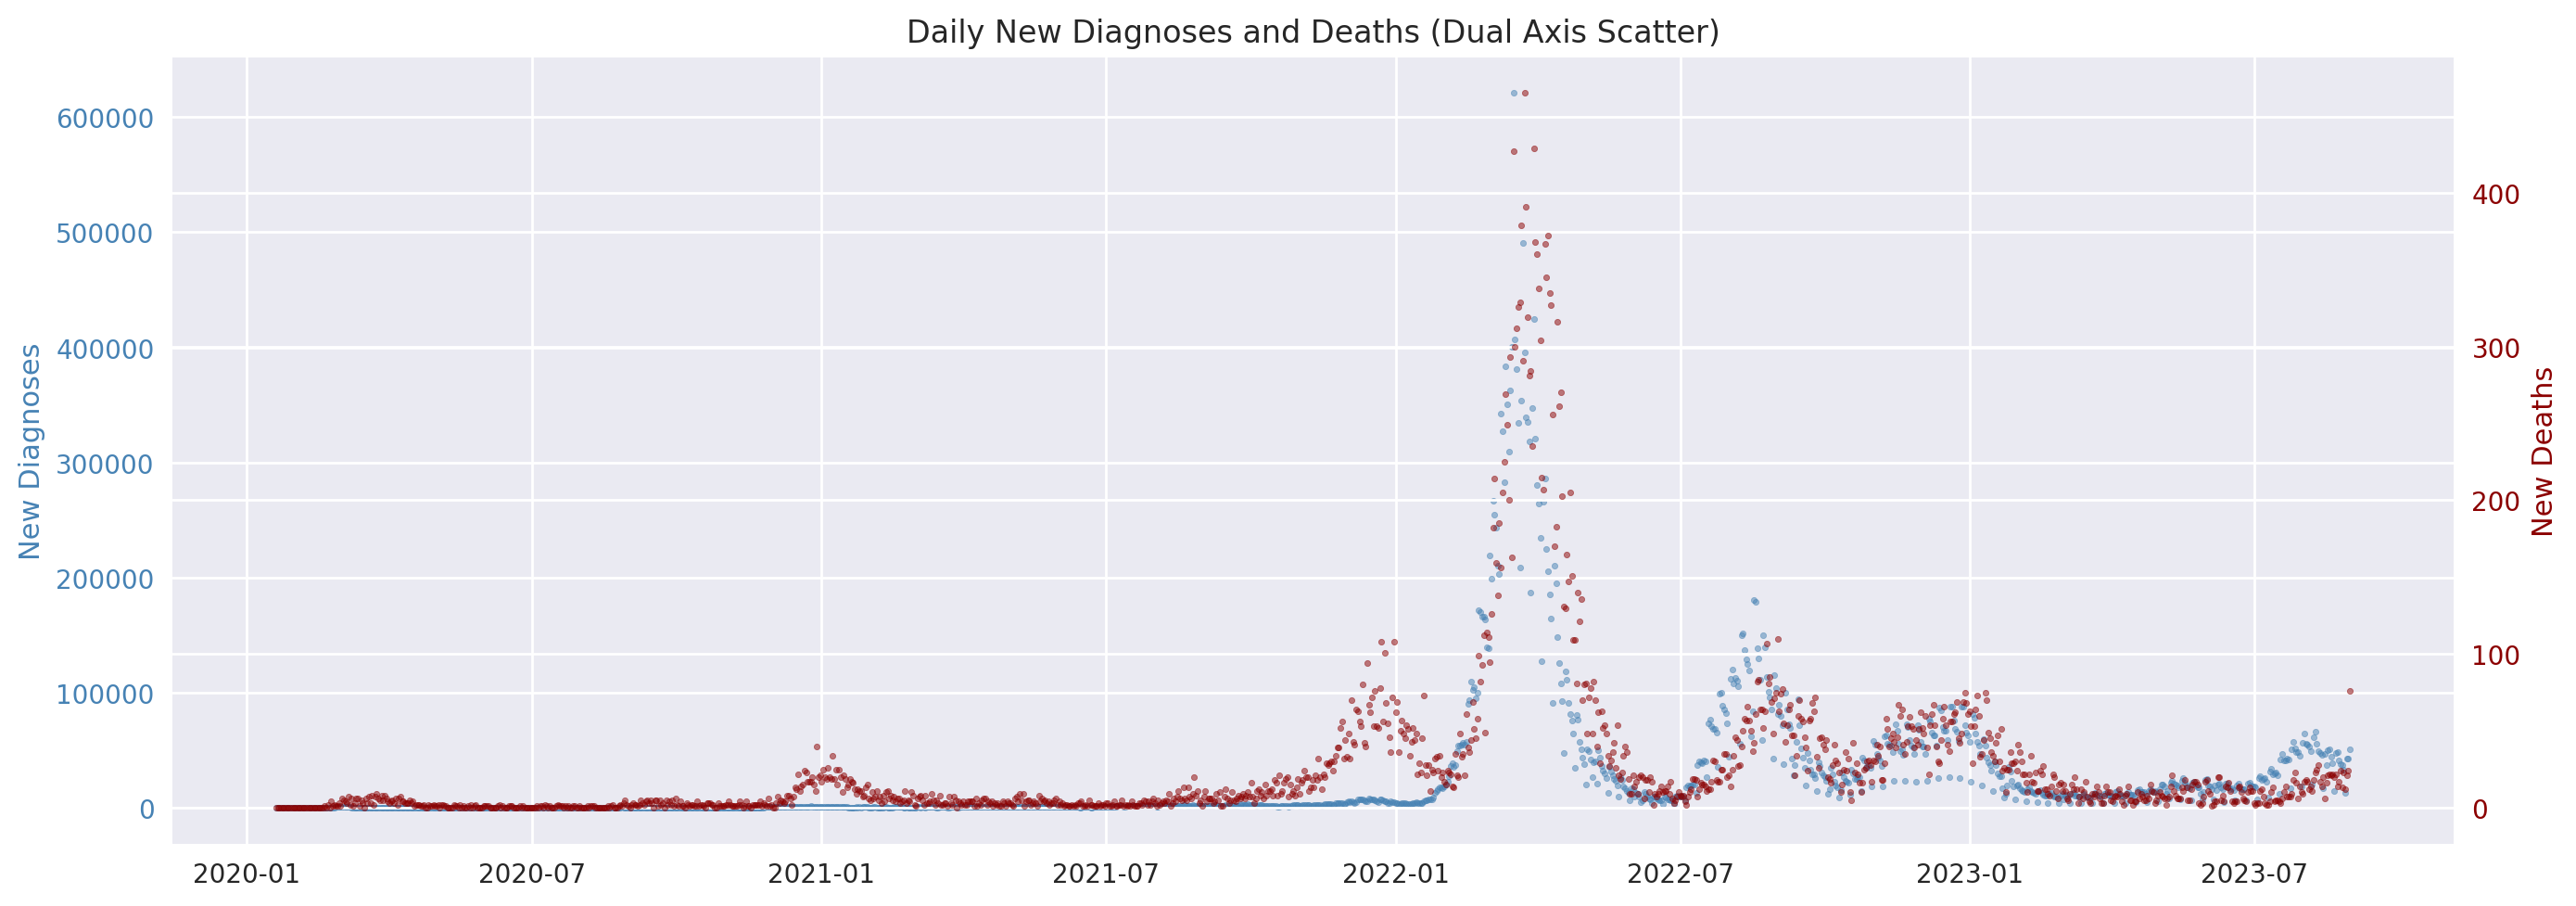

In [10]:
fig, ax1 = plt.subplots(figsize=(14,5))

ax1.scatter(covasim_df["date"], covasim_df["new_diagnoses"], s=5, color="steelblue", alpha=0.5)
ax1.set_ylabel("New Diagnoses", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.scatter(covasim_df["date"], covasim_df["new_deaths"], s=5, color="darkred", alpha=0.5)
ax2.set_ylabel("New Deaths", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

plt.title("Daily New Diagnoses and Deaths (Dual Axis Scatter)")
fig.tight_layout()
plt.show()


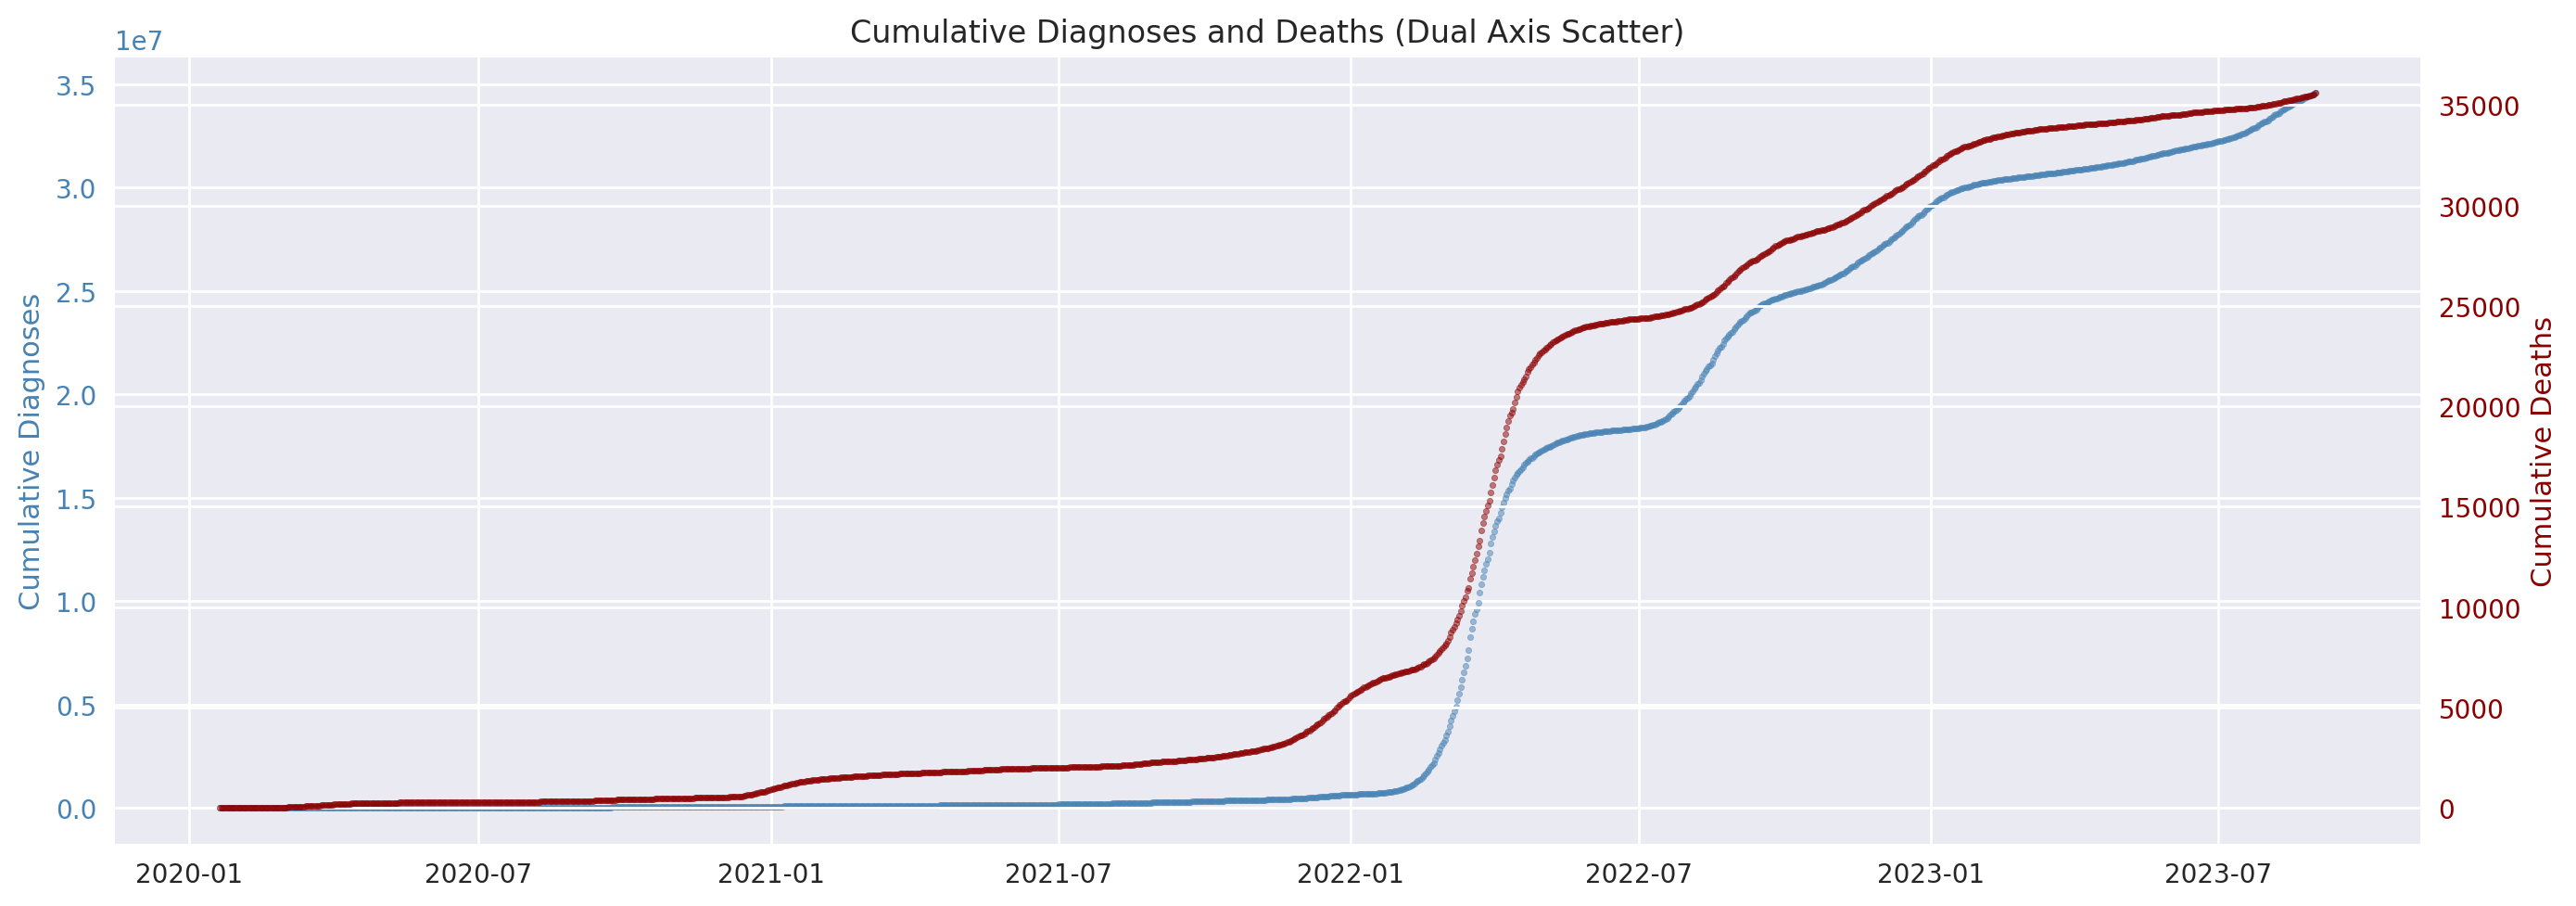

In [11]:
fig, ax1 = plt.subplots(figsize=(14,5))

covasim_df["cum_infections"] = covasim_df["new_diagnoses"].cumsum()
covasim_df["cum_deaths"] = covasim_df["new_deaths"].cumsum()

# Left y-axis: cumulative diagnoses
ax1.scatter(covasim_df["date"], covasim_df["cum_infections"], 
            s=5, color="steelblue", alpha=0.5)
ax1.set_ylabel("Cumulative Diagnoses", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Right y-axis: cumulative deaths
ax2 = ax1.twinx()
ax2.scatter(covasim_df["date"], covasim_df["cum_deaths"], 
            s=5, color="darkred", alpha=0.5)
ax2.set_ylabel("Cumulative Deaths", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

plt.title("Cumulative Diagnoses and Deaths (Dual Axis Scatter)")
fig.tight_layout()
plt.show()


# Simple Simulation
A simple simulation was run with a population size of 10,000. This was intended as a lightweight test to examine baseline model behaviour before calibration. 

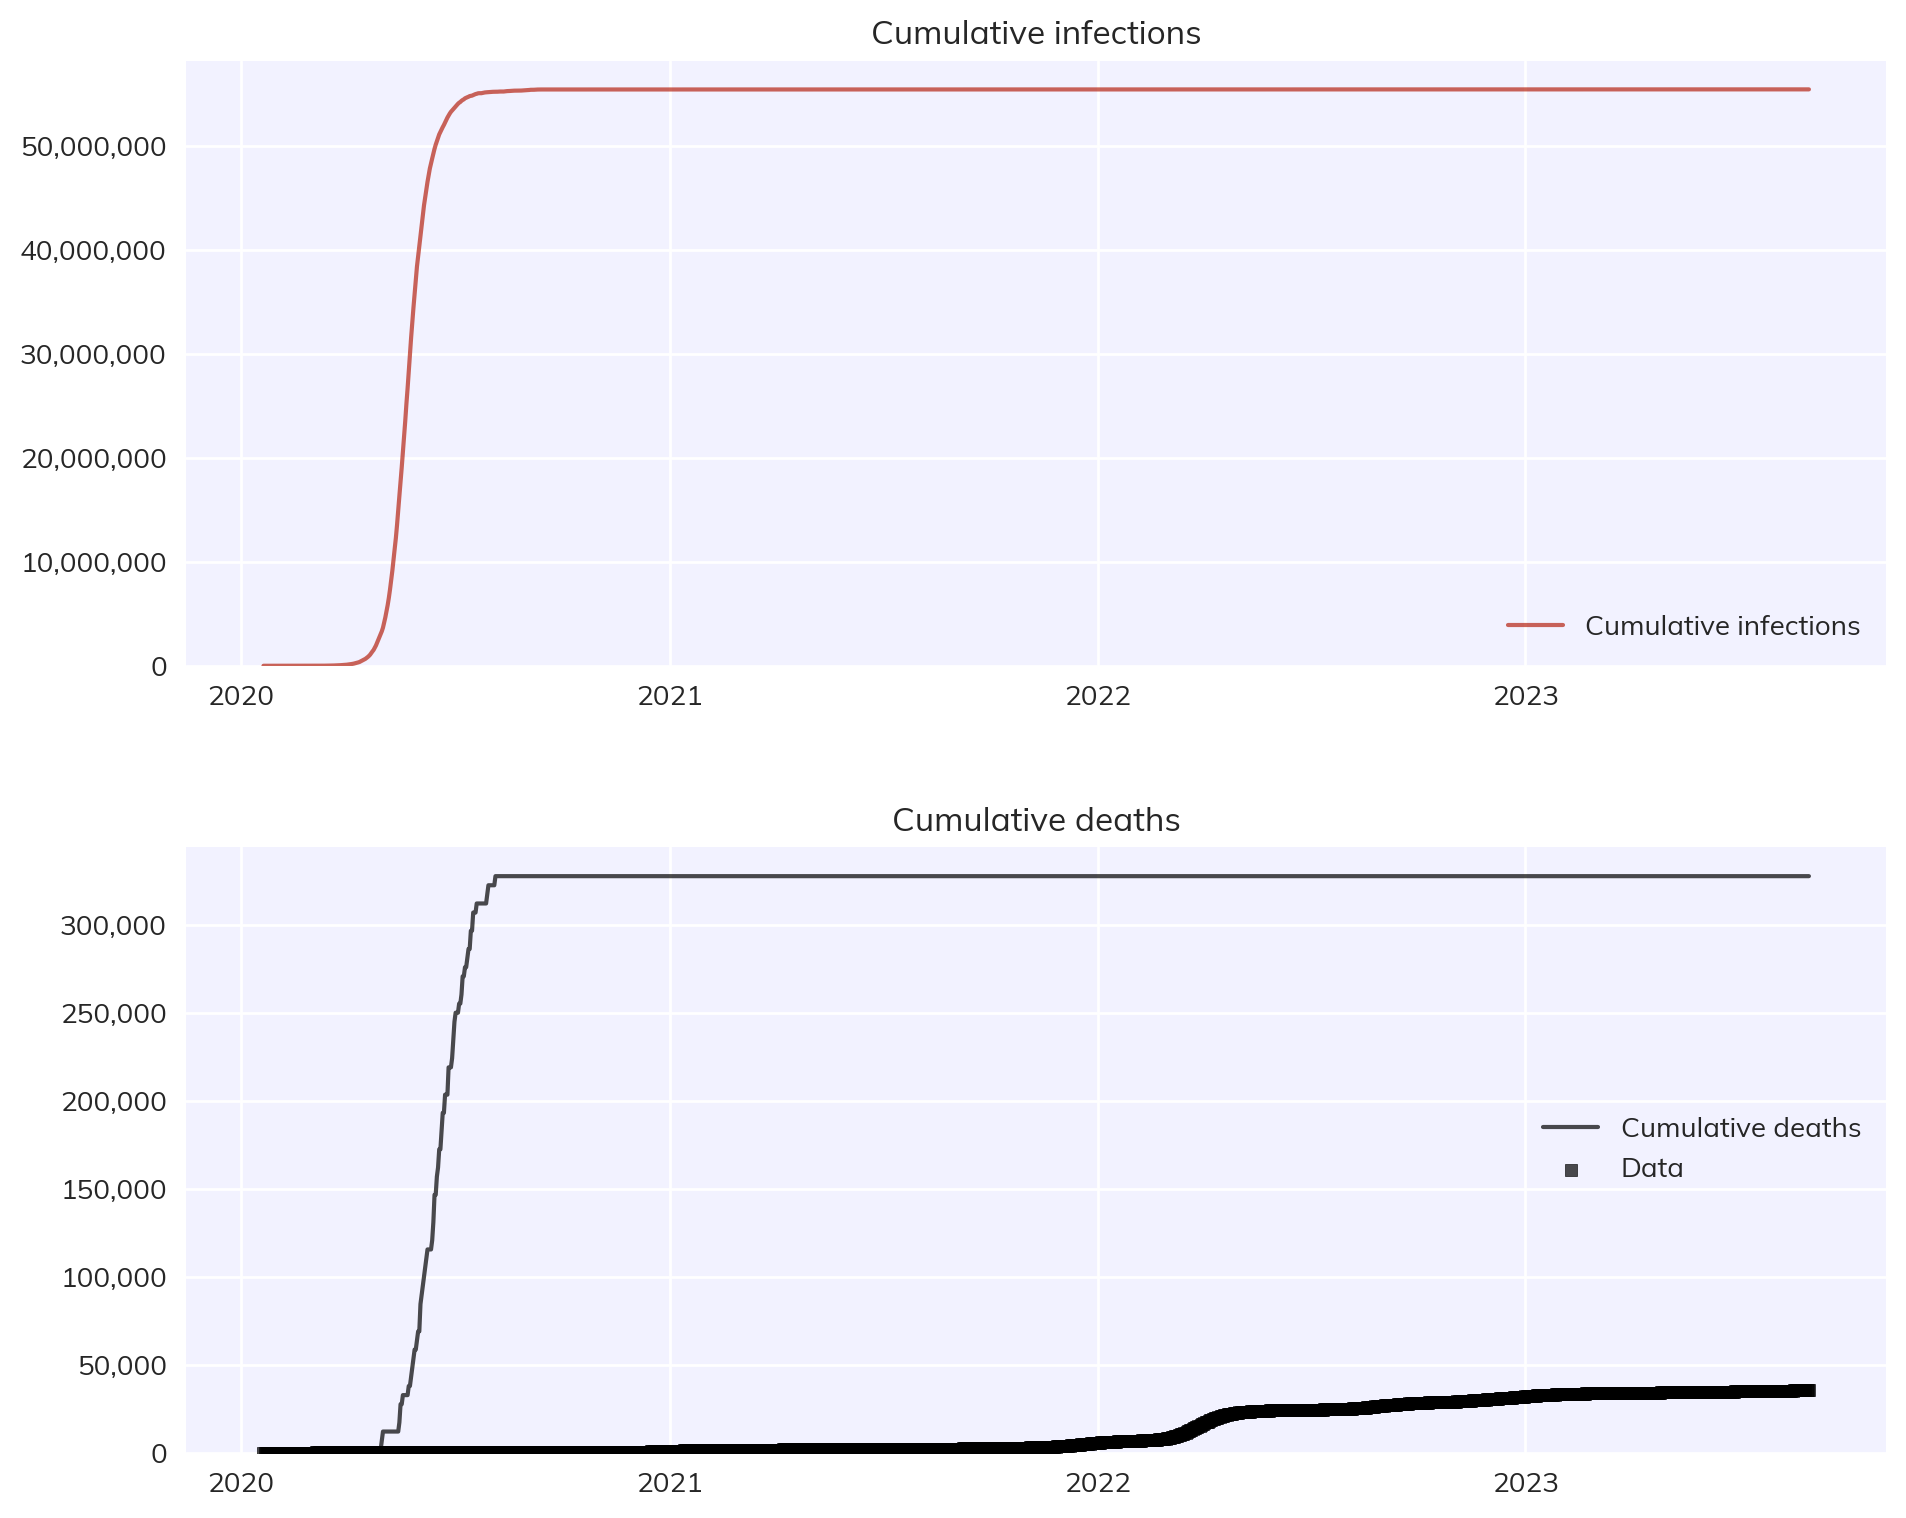

In [12]:
cv.options(jupyter=True, verbose=0)

pars = dict(
    pop_size  = 10_000,
    pop_scale=51780000/10000,
    start_day = '2020-01-20',
    end_day   = '2023-08-31',
)
sim = cv.Sim(pars=pars, datafile='/home/jhkim/covasim_project/jhk_covasim4wastewater/simulation_korea/korea_clean_for_covasim.csv')
sim.run()
sim.plot(to_plot=['cum_infections', 'cum_deaths']) # default plotting


The built-in Covasim plotting was used, but since it did not look good custom plotting was added below.

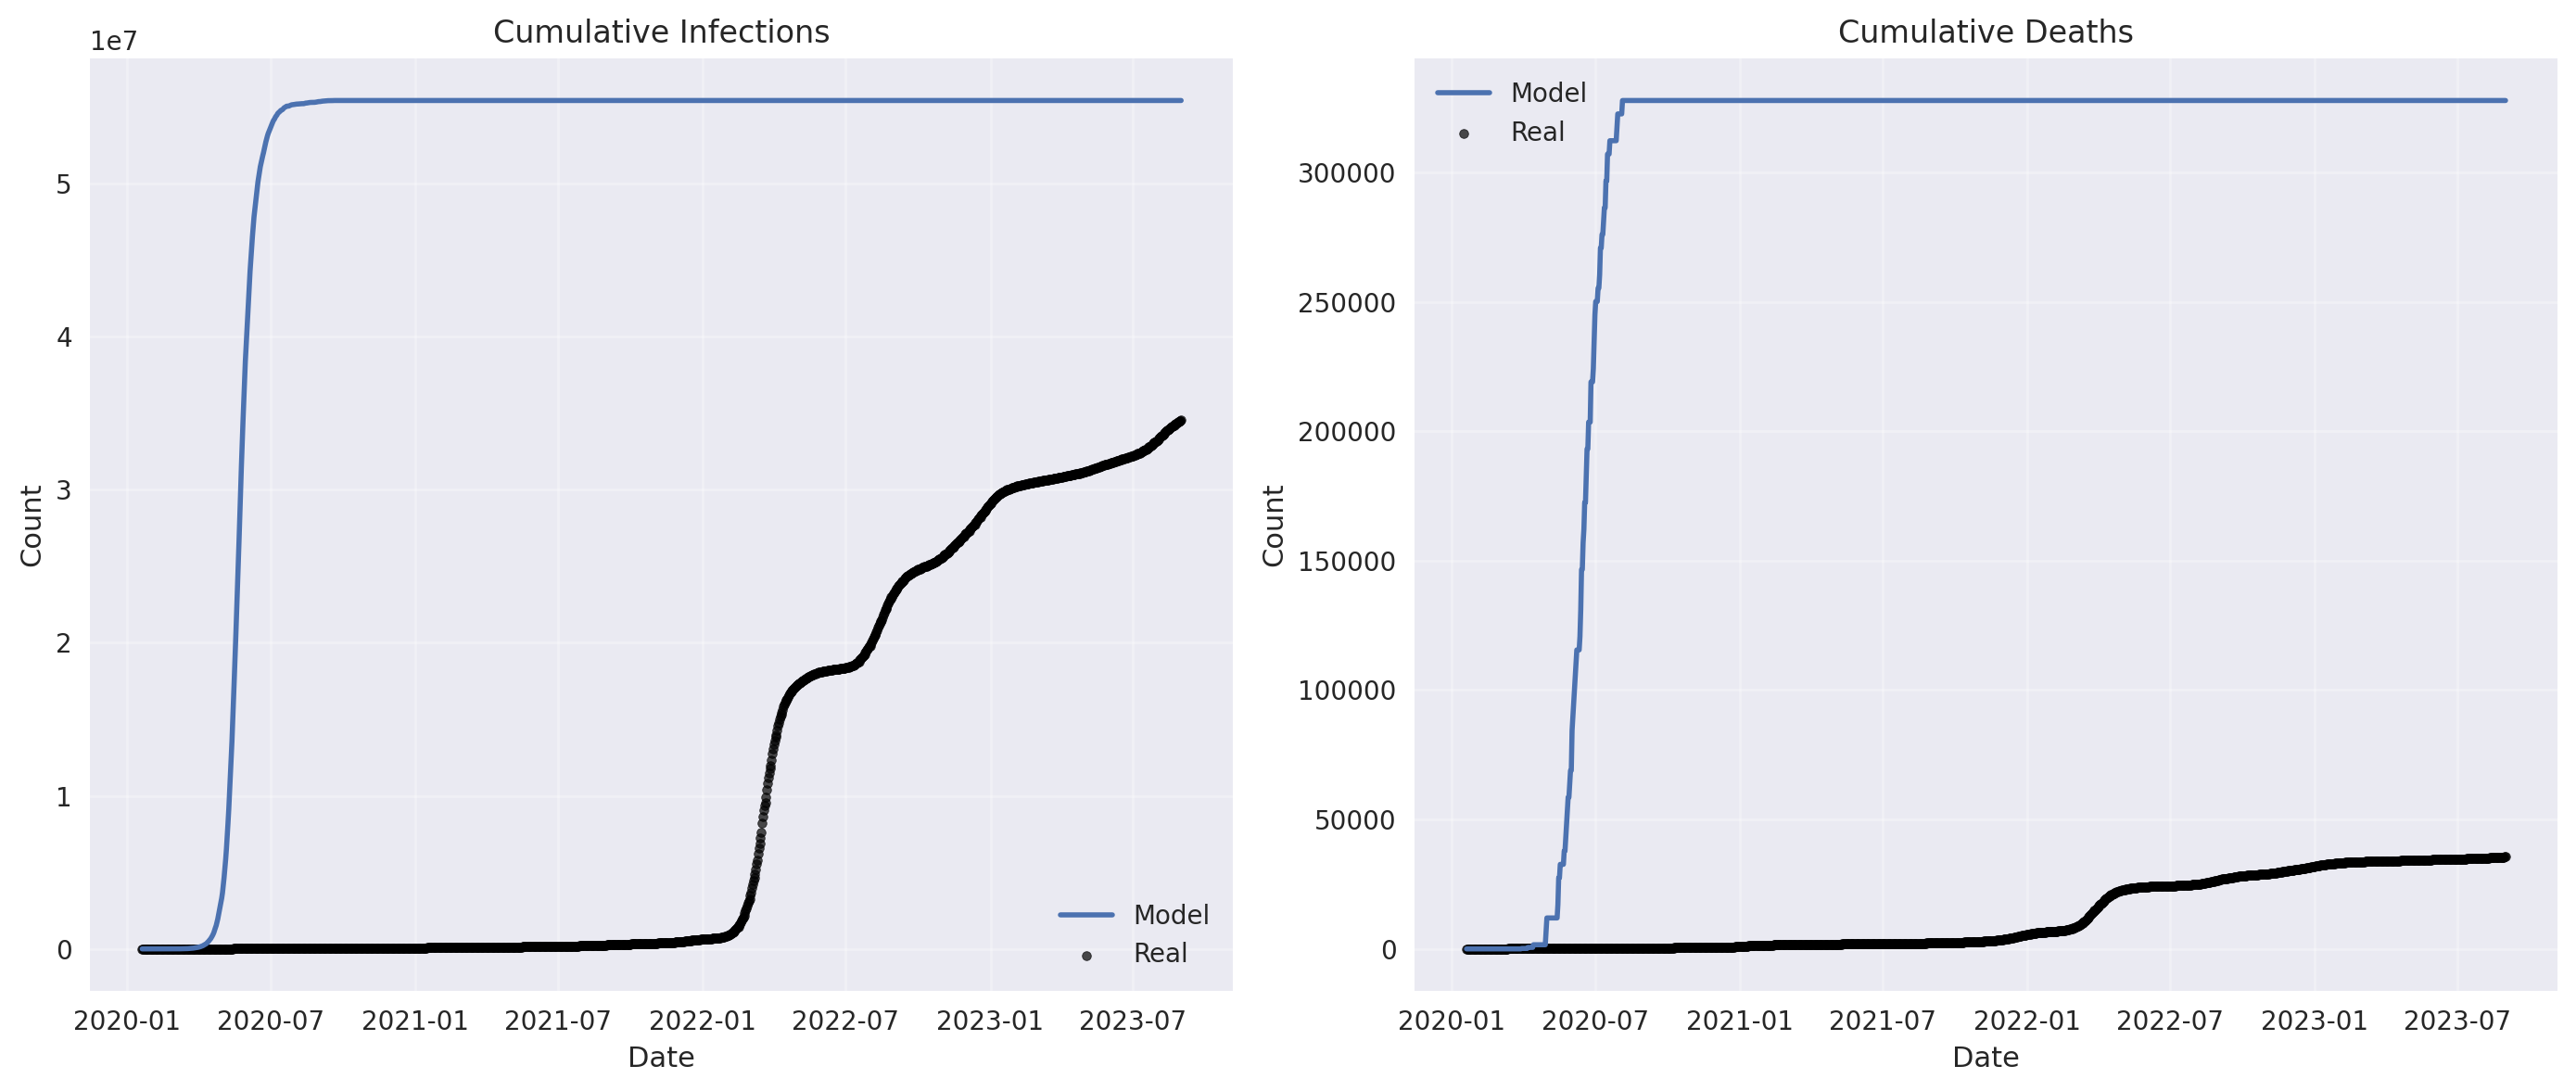

In [20]:
# data prep
df = covasim_df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df["cum_infections"] = df["new_diagnoses"].cumsum()
df["cum_deaths"] = df["new_deaths"].cumsum()


# model output
model_dates = sim.results.date
model_cum_diag = sim.results['cum_infections']
model_cum_death = sim.results['cum_deaths']

# real data
df_plot = df.copy()
df_plot.index = df_plot.index.date

plt.figure(figsize=(14,6))

# diagnoses
plt.subplot(1,2,1)
plt.plot(model_dates, model_cum_diag, lw=2, label="Model")
plt.scatter(df_plot.index, df_plot["cum_infections"], s=12, c='black', alpha=0.7, label="Real")
plt.title("Cumulative Infections")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()

# deaths
plt.subplot(1,2,2)
plt.plot(model_dates, model_cum_death, lw=2, label="Model")
plt.scatter(df_plot.index, df_plot["cum_deaths"], s=12, c='black', alpha=0.7, label="Real")
plt.title("Cumulative Deaths")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
print(sim.summary)

#0. 'cum_infections':      55436823.83333507
#1. 'cum_reinfections':    10124739.638027485
#2. 'cum_infectious':      55373531.30105682
#3. 'cum_symptomatic':     35293567.876904055
#4. 'cum_severe':          2813455.8466606676
#5. 'cum_critical':        850276.5429108231
#6. 'cum_recoveries':      55081865.17822133
#7. 'cum_deaths':          327812.19395258545
#8. 'cum_tests':           0.0
#9. 'cum_diagnoses':       0.0
#10. 'cum_known_deaths':    0.0
#11. 'cum_quarantined':     0.0
#12. 'cum_isolated':        0.0
#13. 'cum_doses':           0.0
#14. 'cum_vaccinated':      0.0
#15. 'new_infections':      0.0
#16. 'new_reinfections':    0.0
#17. 'new_infectious':      0.0
#18. 'new_symptomatic':     0.0
#19. 'new_severe':          0.0
#20. 'new_critical':        0.0
#21. 'new_recoveries':      0.0
#22. 'new_deaths':          0.0
#23. 'new_tests':           0.0
#24. 'new_diagnoses':       0.0
#25. 'new_known_deaths':    0.0
#26. 'new_quarantined':     0.0
#27. 'new_isolated':        0.

The simple simulation does not match the Korean dataset well. In contrast to the Covasim paper where pre-calibration simulation tended to overestimate diagnoses and underestimate deaths, it showed the opposite pattern of simulated diagnoses being much lower and simulated deaths being much higher than observed.

Could not delete study, skipping...
'Record does not exist.'
Removed existing calibration covasim_calibration.db


[I 2026-06-16 15:15:26,795] A new study created in RDB with name: covasim_calibration
[I 2026-06-16 15:15:35,672] Trial 4 finished with value: 117737.11838932798 and parameters: {'beta': 0.02480875163529023, 'rel_death_prob': 1.4524276465877837, 'pop_infected': 3817.5024401973847}. Best is trial 4 with value: 117737.11838932798.
[I 2026-06-16 15:15:37,101] Trial 13 finished with value: 207674.59916736954 and parameters: {'beta': 0.032708273022689055, 'rel_death_prob': 2.641707526760494, 'pop_infected': 3613.4065666530996}. Best is trial 4 with value: 117737.11838932798.
[I 2026-06-16 15:15:38,923] Trial 0 finished with value: 58719.906510449226 and parameters: {'beta': 0.04878417609379136, 'rel_death_prob': 0.31612023712752796, 'pop_infected': 2180.0083620401606}. Best is trial 0 with value: 58719.906510449226.
[I 2026-06-16 15:15:40,944] Trial 11 finished with value: 87655.5822986953 and parameters: {'beta': 0.1631039859722256, 'rel_death_prob': 0.36062421884062823, 'pop_infected': 37

Making results structure...
Processed 216 trials; 0 failed
Deleted study covasim_calibration in sqlite:///covasim_calibration.db
Removed existing calibration covasim_calibration.db
Calibration for 216 total trials completed in 112.9 s.

Initial parameter values:
#0. 'beta':           0.02
#1. 'rel_death_prob': 1.0
#2. 'pop_infected':   200

Best parameter values:
#0. 'beta':           0.0064950097578575445
#1. 'rel_death_prob': 0.5899075262770495
#2. 'pop_infected':   2500.64948362166

Mismatch before calibration: 100056
Mismatch after calibration:  987.486
Percent improvement:         99.0%
#0. 'cum_infections':      7277410.648434175
#1. 'cum_reinfections':    363720.8461197604
#2. 'cum_infectious':      7261671.710646894
#3. 'cum_symptomatic':     4943896.864696331
#4. 'cum_severe':          407601.07103446254
#5. 'cum_critical':        95085.87339036772
#6. 'cum_recoveries':      7262499.437524226
#7. 'cum_deaths':          20966.234363274856
#8. 'cum_tests':           0.0
#9. 'cum

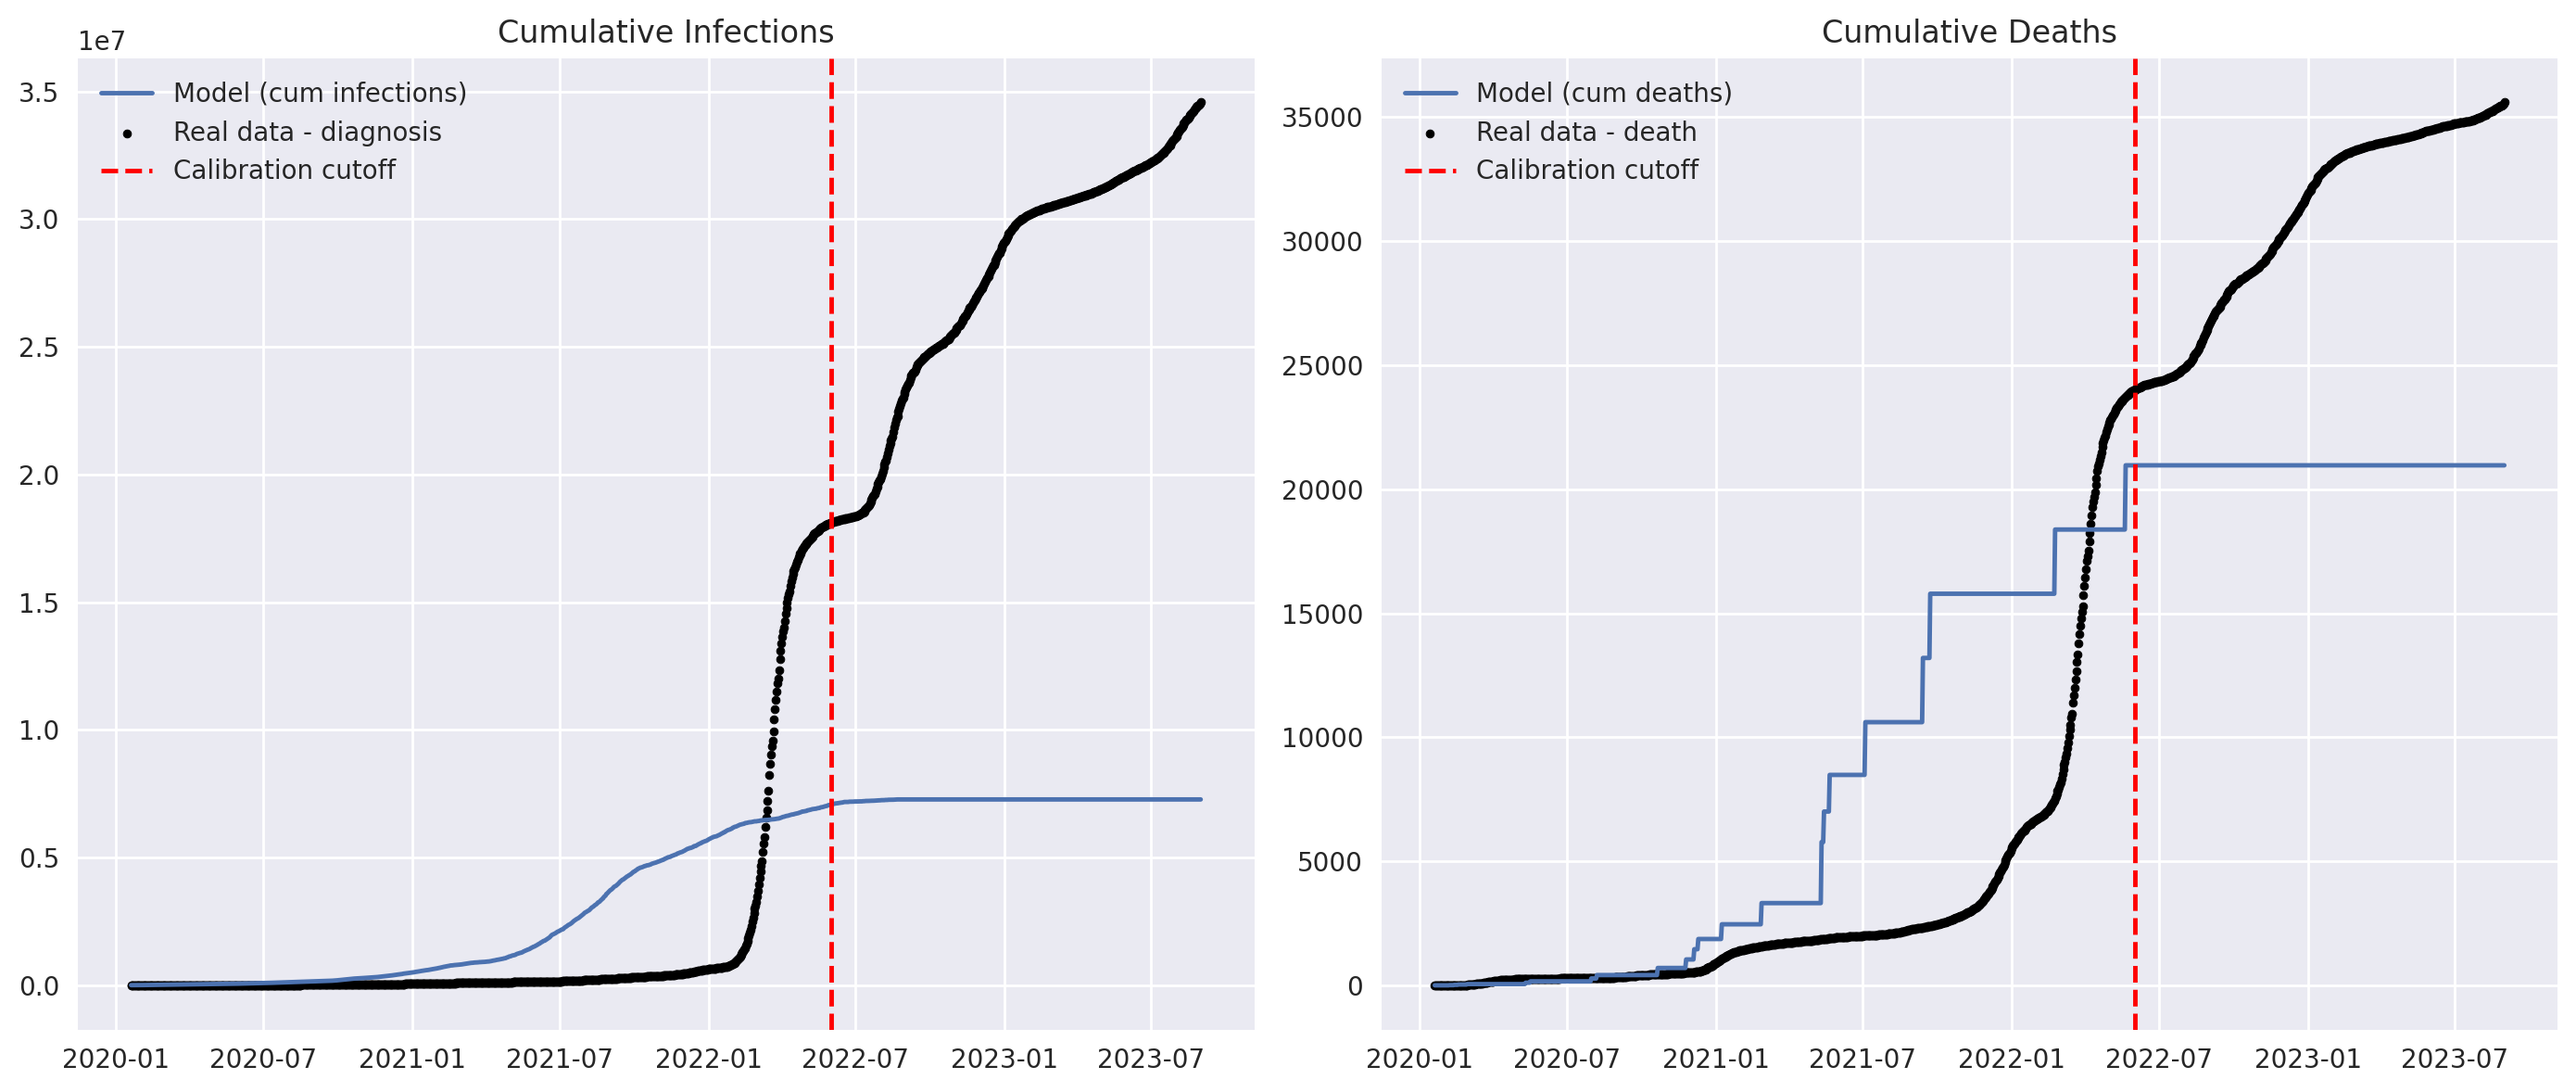

In [25]:
cutoff = pd.to_datetime("2022-06-01")

# data for calibration
df_calib = df.loc[:cutoff, ["cum_infections", "cum_deaths"]]
df_calib.index = df_calib.index.date
df_calib = df_calib.asfreq("D").ffill()
df_calib.to_csv("/home/jhkim/covasim_project/jhk_covasim4wastewater/simulation_korea/calib_data.csv", index_label="date")

# calibration sim
sim_calib = cv.Sim(
    location='South Korea',
    pop_type='hybrid',
    pop_size=10000,
    pop_scale=51780000/10000,
    start_day=df_calib.index.min().strftime("%Y-%m-%d"),
    end_day=df_calib.index.max().strftime("%Y-%m-%d"),
    datafile="/mnt/c/Users/jhkim/OneDrive - The Scripps Research Institute/jhk_covasim4wastewater/simulation_korea/calib_data.csv",
    verbose=0,
)

# calibration parameters
calib_pars = dict(
    beta=[0.02, 0.001, 0.2],
    rel_death_prob=[1.0, 0.1, 3.0],
    pop_infected=[200, 1, 5000],
)

fit_args = dict(
    weights={'cum_deaths': 8, 'cum_infections': 5}
)

calib = sim_calib.calibrate(calib_pars=calib_pars, fit_args=fit_args, total_trials=200)

best_pars = calib.best_pars

# run simulation with best_pars
sim_pred = cv.Sim(
    location='South Korea',
    pop_type='hybrid',
    pop_size=20000,
    pop_scale=51780000/20000,
    start_day=df.index.min().strftime("%Y-%m-%d"),
    end_day=df.index.max().strftime("%Y-%m-%d"),
    verbose=0,
)

sim_pred.update_pars(best_pars)
sim_pred.run()

print(sim_pred.summary)

# extract model output
model_dates = sim_pred.results.date
model_cum_diag = sim_pred.results['cum_infections']
model_cum_death = sim_pred.results['cum_deaths']

# prep real data
df_plot = df.copy()
df_plot.index = df_plot.index.date

# compare graph
plt.figure(figsize=(14,6))

# diagnoses
plt.subplot(1,2,1)
plt.plot(model_dates, model_cum_diag, label="Model (cum infections)")
plt.scatter(df_plot.index, df_plot["cum_infections"], s=10, c='k', label="Real data - diagnosis")
plt.axvline(cutoff.date(), color='red', linestyle='--', label="Calibration cutoff")
plt.title("Cumulative Infections")
plt.legend()

# deaths
plt.subplot(1,2,2)
plt.plot(model_dates, model_cum_death, label="Model (cum deaths)")
plt.scatter(df_plot.index, df_plot["cum_deaths"], s=10, c='k', label="Real data - death")
plt.axvline(cutoff.date(), color='red', linestyle='--', label="Calibration cutoff")
plt.title("Cumulative Deaths")
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
print(sim_pred.summary)

#0. 'cum_infections':      171346.8761186515
#1. 'cum_reinfections':    3261.690474035224
#2. 'cum_infectious':      152476.9234426208
#3. 'cum_symptomatic':     103810.70892480534
#4. 'cum_severe':          8851.375027869295
#5. 'cum_critical':        2466.574620953884
#6. 'cum_recoveries':      150715.29926189574
#7. 'cum_deaths':          1717.5500222924343
#8. 'cum_tests':           0.0
#9. 'cum_diagnoses':       0.0
#10. 'cum_known_deaths':    0.0
#11. 'cum_quarantined':     0.0
#12. 'cum_isolated':        0.0
#13. 'cum_doses':           0.0
#14. 'cum_vaccinated':      0.0
#15. 'new_infections':      0.0
#16. 'new_reinfections':    0.0
#17. 'new_infectious':      0.0
#18. 'new_symptomatic':     0.0
#19. 'new_severe':          0.0
#20. 'new_critical':        0.0
#21. 'new_recoveries':      0.0
#22. 'new_deaths':          0.0
#23. 'new_tests':           0.0
#24. 'new_diagnoses':       0.0
#25. 'new_known_deaths':    0.0
#26. 'new_quarantined':     0.0
#27. 'new_isolated':        0.0

Even after the calibration, the fitted simulation still underestimates diagnoses and overestimates deaths although the discrepancies are somewhat reduced.

During the calibration process, Covasim attempts to identify a single optimal parameter set, most importantly a single Beta value across the entire simulation period. Fitting one global beta for the entire epidemic likely forces the model into unrealistic trade‑offs, which may explain the persistent mismatch.

The Covasim paper reports that their model successfully captured multiple epidemic waves in the given dataset. Therefore, examining how many times beta or other key parameters were adjusted across those waves would be important.

# Potential Improvement
A promising enhancement would be to implement automatic time‑segmented calibration, where the simulation period is divided into meaningful intervals such as variant‑dominant phases, and beta is optimized separately for each segment. This would allow the model to better reflect real changes in transmissibility over time and could substantially improve fit quality.